In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
benin = pd.read_csv(r"../data/benin.csv", encoding="latin1")
togo =pd.read_csv(r"../data/togo.csv", encoding="latin1")
sierra = pd.read_csv(r"../data/sierraleone.csv", encoding="latin1")

C:\Users\Fitsum\AppData\Local\Temp\ipykernel_4368\823581896.py:1: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  benin = pd.read_csv(r"../data/benin.csv", encoding="latin1")
C:\Users\Fitsum\AppData\Local\Temp\ipykernel_4368\823581896.py:2: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  togo =pd.read_csv(r"../data/togo.csv", encoding="latin1")
C:\Users\Fitsum\AppData\Local\Temp\ipykernel_4368\823581896.py:3: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  sierra = pd.read_csv(r"../data/sierraleone.csv", encoding="latin1")


In [3]:
benin['Country'] = 'Benin'
togo['Country'] = 'Togo'
sierra['Country'] = 'Sierra Leone'


In [4]:
df_all = pd.concat([benin, togo, sierra])


In [6]:
for df in [benin, togo, sierra]:
    df['GHI'] = df['GHI'].str.replace(r'[^\d.-]', '', regex=True)  # Remove non-numeric characters
    df['GHI'] = pd.to_numeric(df['GHI'], errors='coerce')  # Convert to numeric, replacing invalid values with NaN
for df in [benin, togo, sierra]:
    df['GHI'].fillna(df['GHI'].median(), inplace=True)  # Replace NaN with the median

C:\Users\Fitsum\AppData\Local\Temp\ipykernel_4368\1015682436.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GHI'].fillna(df['GHI'].median(), inplace=True)  # Replace NaN with the median
C:\Users\Fitsum\AppData\Local\Temp\ipykernel_4368\1015682436.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

In [11]:
# Drop rows where 'Country' or 'GHI' is missing
df_all = df_all.dropna(subset=['Country', 'GHI'])

# Convert 'Country' to string type to prevent errors
df_all['Country'] = df_all['Country'].astype(str)

# Ensure GHI is numeric (optional but good practice)
df_all['GHI'] = pd.to_numeric(df_all['GHI'], errors='coerce')


In [13]:
# Remove duplicated column names
df_all = df_all.loc[:, ~df_all.columns.duplicated()]


In [15]:
print(df_all.columns)


Index(['Timestamp', 'GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS',
       'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation',
       'TModA', 'TModB', 'Comments', 'Country', 'GHIrsi'],
      dtype='object')


In [16]:
df_all.index.duplicated().sum()


np.int64(1051202)

In [17]:
df_all = df_all.reset_index(drop=True)


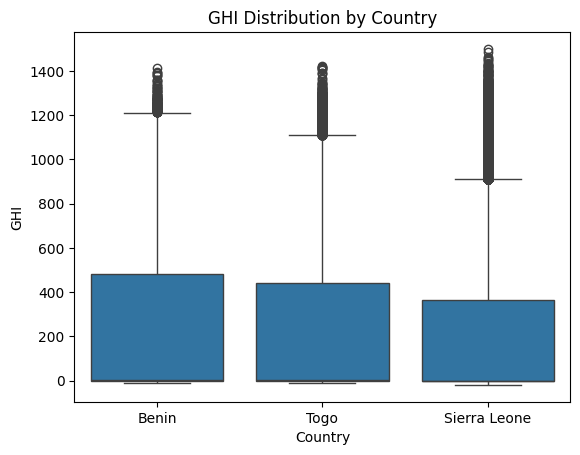

In [18]:
sns.boxplot(x='Country', y='GHI', data=df_all)
plt.title('GHI Distribution by Country')
plt.show()

In [20]:
for col in ['GHI', 'DNI', 'DHI']:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')
df_all[['GHI', 'DNI', 'DHI']] = df_all[['GHI', 'DNI', 'DHI']].fillna(0)  # Replace NaN with 0 or another value

In [21]:
df_all.groupby('Country')[['GHI', 'DNI', 'DHI']].agg(['mean', 'median', 'std'])


GHI                            DNI                     \
                    mean median         std        mean median         std   
Country                                                                      
Benin         240.558995    1.8  331.131179  167.187198   -0.1  261.710353   
Sierra Leone  201.957131    0.3  298.494996  116.376116   -0.1  218.652510   
Togo          230.554601    2.1  322.532197  151.258181    0.0  250.956810   

                     DHI                     
                    mean median         std  
Country                                      
Benin         115.358741    1.6  158.691003  
Sierra Leone  113.720354   -0.1  158.945958  
Togo          116.444131    2.5  156.520647

In [22]:
from scipy.stats import f_oneway

f_oneway(benin['GHI'], togo['GHI'], sierra['GHI'])


F_onewayResult(statistic=np.float64(290.440494623011), pvalue=np.float64(7.700590963353791e-127))